In [4]:
# =====================================================
# IMPORTS (consolidated - no duplicates)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.patches import FancyArrowPatch
from xgboost import XGBClassifier

# Set style globally
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/CCIR_Data-Collection Final.xlsx")
df = df.iloc[1:].reset_index(drop=True)
df.columns = [
    "Form", "Age", "Gender", "Profession", "Date",
    "Q1", "Q2", "Q3", "Q4", "Q5", "Q6",
    "Q7", "Q8", "Q9", "Q10", "Q11",
    "Q12", "Q13", "Q14", "Q15", "Q16"
]
df.replace("-", np.nan, inplace=True)

/tmp/ipykernel_1779/3362958042.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("-", np.nan, inplace=True)


In [6]:
# =====================================================
# CREATE DEPENDENT VARIABLES
# =====================================================

# Q4: Attempt
df["Attempt"] = df["Q4"].map({"a": 0, "b": 1})

# Q6: Success
df["Success"] = df["Q6"].map({
    "d": 0, "a": 1, "b": 1, "c": 1
}).fillna(0)

print("=" * 70)
print("DUAL ANALYSIS: RECOVERY ATTEMPTS (Q4) vs SUCCESS (Q6)")
print("=" * 70)
print(f"\nQ4 (Attempt): {(df['Attempt']==1).sum()}/{len(df)} tried to stop "
      f"({(df['Attempt']==1).sum()/len(df)*100:.1f}%)")
print(f"Q6 (Success): {(df['Success']==1).sum()}/{len(df)} achieved sobriety "
      f"({(df['Success']==1).sum()/len(df)*100:.1f}%)")
print(f"\n💡 Success rate among those who tried: "
      f"{(df['Success']==1).sum()}/{(df['Attempt']==1).sum()} = "
      f"{(df['Success']==1).sum()/(df['Attempt']==1).sum()*100:.1f}%")

DUAL ANALYSIS: RECOVERY ATTEMPTS (Q4) vs SUCCESS (Q6)

Q4 (Attempt): 29/40 tried to stop (72.5%)
Q6 (Success): 1/40 achieved sobriety (2.5%)

💡 Success rate among those who tried: 1/29 = 3.4%


In [7]:
# =====================================================
# SHARED ANALYSIS (PCA + CLUSTERING)
# =====================================================

features_shared = df.drop(columns=[
    "Form", "Date", "Q4", "Q5", "Q6", "Attempt", "Success"
])
features_shared = features_shared.fillna(0)
X_shared = pd.get_dummies(features_shared, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_shared)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f"\n{'='*70}")
print("PCA - Explained Variance (Top 5):")
for i, var in enumerate(pca.explained_variance_ratio_[:5], 1):
    print(f"  PC{i}: {var*100:.2f}%")

# K-Means Clustering (needed before Q4/Q6 analyses which drop "Cluster")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)


PCA - Explained Variance (Top 5):
  PC1: 13.76%
  PC2: 9.84%
  PC3: 7.89%
  PC4: 7.34%
  PC5: 6.61%


In [8]:
# --- Build Q4 features first (shared by Model Comparison + Analysis 1) ---
features_q4 = df.drop(columns=["Form", "Date", "Q4", "Q5", "Q6",
                                "Attempt", "Success", "Cluster"])
X_q4 = pd.get_dummies(features_q4, drop_first=True)
y_q4 = df["Attempt"].dropna()
X_q4 = X_q4.loc[y_q4.index]

X_train_q4, X_test_q4, y_train_q4, y_test_q4 = train_test_split(
    X_q4, y_q4, test_size=0.3, random_state=42, stratify=y_q4
)

# Train the selected Decision Tree now so it's available for comparison table
dt_q4 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3, random_state=42)
dt_q4.fit(X_train_q4, y_train_q4)
y_pred_q4 = dt_q4.predict(X_test_q4)

In [9]:
# =====================================================
# MODEL COMPARISON
# =====================================================

print(f"\n{'='*70}")
print("MODEL SELECTION PROCESS: SYSTEMATIC COMPARISON")
print("=" * 70)

results = []

X_comp = X_q4
y_comp = y_q4
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_comp, y_comp, test_size=0.3, random_state=42, stratify=y_comp
)

# 1. Logistic Regression
print("\n1️⃣ LOGISTIC REGRESSION")
print("-" * 70)
try:
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_c, y_train_c)
    train_acc_lr = lr.score(X_train_c, y_train_c)
    test_acc_lr  = lr.score(X_test_c,  y_test_c)
    y_pred_lr    = lr.predict(X_test_c)
    print(f"✅ Training Accuracy: {train_acc_lr:.2%}")
    print(f"✅ Testing  Accuracy: {test_acc_lr:.2%}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_c, y_pred_lr))
    results.append({
        'Model': 'Logistic Regression',
        'Train_Acc': train_acc_lr,
        'Test_Acc': test_acc_lr,
        'Overfitting': train_acc_lr - test_acc_lr,
        'Status': '✅ Works (for Q4)'
    })
except Exception as e:
    print(f"❌ Failed: {e}")
    results.append({
        'Model': 'Logistic Regression',
        'Train_Acc': None, 'Test_Acc': None, 'Overfitting': None,
        'Status': '❌ Failed (ordinal data issue)'
    })

# 2. XGBoost
print("\n2️⃣ XGBOOST")
print("-" * 70)
xgb = XGBClassifier(n_estimators=100, max_depth=5,
                    random_state=42, eval_metric='logloss')
xgb.fit(X_train_c, y_train_c)
train_acc_xgb = xgb.score(X_train_c, y_train_c)
test_acc_xgb  = xgb.score(X_test_c,  y_test_c)
y_pred_xgb    = xgb.predict(X_test_c)
print(f"Training Accuracy: {train_acc_xgb:.2%}")
print(f"Testing  Accuracy: {test_acc_xgb:.2%}")
print(f"⚠️  Overfitting Gap: {(train_acc_xgb - test_acc_xgb)*100:.1f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_xgb))
results.append({
    'Model': 'XGBoost',
    'Train_Acc': train_acc_xgb,
    'Test_Acc': test_acc_xgb,
    'Overfitting': train_acc_xgb - test_acc_xgb,
    'Status': ('❌ Severe overfitting'
               if (train_acc_xgb - test_acc_xgb) > 0.3
               else '⚠️ Moderate overfitting')
})

# 3. Random Forest
print("\n3️⃣ RANDOM FOREST")
print("-" * 70)
rf_comp = RandomForestClassifier(n_estimators=100, max_depth=3,
                                 min_samples_leaf=3, random_state=42)
rf_comp.fit(X_train_c, y_train_c)
train_acc_rf    = rf_comp.score(X_train_c, y_train_c)
test_acc_rf     = rf_comp.score(X_test_c,  y_test_c)
y_pred_rf_comp  = rf_comp.predict(X_test_c)
positives_predicted = (y_pred_rf_comp == 1).sum()
print(f"Training Accuracy: {train_acc_rf:.2%}")
print(f"Testing  Accuracy: {test_acc_rf:.2%}")
print(f"Overfitting Gap:   {(train_acc_rf - test_acc_rf)*100:.1f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_rf_comp))
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf_comp, zero_division=0))
print(f"\n⚠️  Positive cases predicted: {positives_predicted}/{len(y_test_c)}")
results.append({
    'Model': 'Random Forest',
    'Train_Acc': train_acc_rf,
    'Test_Acc': test_acc_rf,
    'Overfitting': train_acc_rf - test_acc_rf,
    'Status': ('⚠️ Fails to predict positives'
               if positives_predicted == 0 else '✅ Works')
})

# 4. Decision Tree (already trained above)
train_acc_dt = dt_q4.score(X_train_q4, y_train_q4)
test_acc_dt  = dt_q4.score(X_test_q4,  y_test_q4)
results.append({
    'Model': 'Decision Tree',
    'Train_Acc': train_acc_dt,
    'Test_Acc': test_acc_dt,
    'Overfitting': train_acc_dt - test_acc_dt,
    'Status': '✅ Selected (best balance)'
})

# Comparison table
print(f"\n{'='*70}")
print("FINAL MODEL COMPARISON")
print("=" * 70)
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))
print(f"\n💡 DECISION:")
print("Selected Decision Tree due to:")
print("  1. Minimal overfitting")
print("  2. Successfully predicts both classes")
print("  3. Interpretable for social science research")
print("  4. Appropriate complexity for sample size")


MODEL SELECTION PROCESS: SYSTEMATIC COMPARISON

1️⃣ LOGISTIC REGRESSION
----------------------------------------------------------------------
✅ Training Accuracy: 92.86%
✅ Testing  Accuracy: 91.67%

Confusion Matrix:
[[2 1]
 [0 9]]

2️⃣ XGBOOST
----------------------------------------------------------------------
Training Accuracy: 100.00%
Testing  Accuracy: 75.00%
⚠️  Overfitting Gap: 25.0%

Confusion Matrix:
[[2 1]
 [2 7]]

3️⃣ RANDOM FOREST
----------------------------------------------------------------------
Training Accuracy: 75.00%
Testing  Accuracy: 75.00%
Overfitting Gap:   0.0%

Confusion Matrix:
[[0 3]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.75      1.00      0.86         9

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12


⚠️  Positive cas

In [10]:
# =====================================================
# ANALYSIS 1: Q4 (ATTEMPT) — full reporting
# =====================================================

print(f"\n{'='*70}")
print("ANALYSIS 1: PREDICTING RECOVERY ATTEMPTS (Q4)")
print("=" * 70)

print("\nDecision Tree Performance:")
print(confusion_matrix(y_test_q4, y_pred_q4))
print(classification_report(y_test_q4, y_pred_q4, zero_division=0))

importance_q4 = pd.Series(dt_q4.feature_importances_, index=X_q4.columns)
print("\nTop 10 Predictors:")
print(importance_q4.sort_values(ascending=False).head(10))


ANALYSIS 1: PREDICTING RECOVERY ATTEMPTS (Q4)

Decision Tree Performance:
[[2 1]
 [2 7]]
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.88      0.78      0.82         9

    accuracy                           0.75        12
   macro avg       0.69      0.72      0.70        12
weighted avg       0.78      0.75      0.76        12


Top 10 Predictors:
Q12_b                  0.320856
Age                    0.301982
Q2_b                   0.188927
Profession_Worker      0.188235
Profession_Student     0.000000
Profession_Retired     0.000000
Gender_Male            0.000000
Q1_c                   0.000000
Q1_b                   0.000000
Q2_d                   0.000000
dtype: float64


In [11]:
# =====================================================
# ANALYSIS 2: Q6 (SUCCESS)
# =====================================================

print(f"\n{'='*70}")
print("ANALYSIS 2: PREDICTING RECOVERY SUCCESS (Q6)")
print("=" * 70)
print("⚠️  Note: Using full dataset due to extreme class imbalance (n_positive=1)")

features_q6 = df.drop(columns=["Form", "Date", "Q5", "Q6", "Success", "Cluster"])
X_q6 = pd.get_dummies(features_q6, drop_first=True)
y_q6 = df["Success"]

dt_q6 = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=2,
    random_state=42, class_weight='balanced'
)
dt_q6.fit(X_q6, y_q6)
y_pred_q6 = dt_q6.predict(X_q6)

print("\nDecision Tree Performance (Full Dataset):")
print("Confusion Matrix:")
print(confusion_matrix(y_q6, y_pred_q6))
print("\nClassification Report:")
print(classification_report(y_q6, y_pred_q6, zero_division=0))
print("\n⚠️  Note: These are training metrics, not test metrics.")
print("With n=1 positive case, traditional train/test split is not feasible.")

importance_q6 = pd.Series(dt_q6.feature_importances_, index=X_q6.columns)
print("\nTop 10 Predictors:")
top10_q6 = importance_q6.sort_values(ascending=False).head(10)
print(top10_q6)

print("\n🎯 Decision Path for 1 Successful Case:")
successful_indices = df[df["Success"] == 1].index
for idx in successful_indices:
    sample = X_q6.loc[idx:idx]
    dt_q6.decision_path(sample)
    print(f"\nCase {idx}:")
    print(f"  Age:              {df.loc[idx, 'Age']}")
    print(f"  Profession:       {df.loc[idx, 'Profession']}")
    print(f"  Q13 (Life impact):{df.loc[idx, 'Q13']}")
    print(f"  Predicted: {'Sober' if dt_q6.predict(sample)[0]==1 else 'Not Sober'}")


ANALYSIS 2: PREDICTING RECOVERY SUCCESS (Q6)
⚠️  Note: Using full dataset due to extreme class imbalance (n_positive=1)

Decision Tree Performance (Full Dataset):
Confusion Matrix:
[[38  1]
 [ 0  1]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99        39
         1.0       0.50      1.00      0.67         1

    accuracy                           0.97        40
   macro avg       0.75      0.99      0.83        40
weighted avg       0.99      0.97      0.98        40


⚠️  Note: These are training metrics, not test metrics.
With n=1 positive case, traditional train/test split is not feasible.

Top 10 Predictors:
Q13_c                  0.902256
Age                    0.097744
Attempt                0.000000
Profession_Retired     0.000000
Gender_Male            0.000000
Profession_Worker      0.000000
Q1_b                   0.000000
Q1_c                   0.000000
Profession_Student     0.000000
Q1_d         

In [12]:
# =====================================================
# COMPARISON: ATTEMPT vs SUCCESS PREDICTORS
# =====================================================

print(f"\n{'='*70}")
print("COMPARISON: ATTEMPT vs SUCCESS PREDICTORS")
print("=" * 70)

q4_top10 = set(importance_q4.nlargest(10).index)
q6_top10 = set(importance_q6.nlargest(10).index)

print("\n🔵 Important for BOTH (Attempt AND Success):")
both = q4_top10 & q6_top10
for feat in both:
    print(f"  - {feat}")

print("\n🟢 Unique to Q4 (Attempt ONLY):")
q4_only = q4_top10 - q6_top10
for feat in q4_only:
    print(f"  - {feat}: {importance_q4[feat]:.3f}")

print("\n🟡 Unique to Q6 (Success ONLY):")
q6_only = q6_top10 - q4_top10
for feat in q6_only:
    print(f"  - {feat}: {importance_q6[feat]:.3f}")

print(f"\n{'='*70}")
print("KEY INSIGHT:")
print("=" * 70)
print(f"Features predicting ATTEMPT:  {len(q4_top10)}")
print(f"Features predicting SUCCESS:  {len(q6_top10)}")
print(f"Overlap:                      {len(both)} features")
print(f"\n💡 Conclusion: "
      f"{'Same factors' if len(both) > 6 else 'DIFFERENT factors'} "
      f"drive attempts vs. success!")


COMPARISON: ATTEMPT vs SUCCESS PREDICTORS

🔵 Important for BOTH (Attempt AND Success):
  - Q1_c
  - Profession_Student
  - Q1_b
  - Profession_Worker
  - Gender_Male
  - Age
  - Q1_d
  - Profession_Retired 

🟢 Unique to Q4 (Attempt ONLY):
  - Q12_b: 0.321
  - Q2_b: 0.189

🟡 Unique to Q6 (Success ONLY):
  - Attempt: 0.000
  - Q13_c: 0.902

KEY INSIGHT:
Features predicting ATTEMPT:  10
Features predicting SUCCESS:  10
Overlap:                      8 features

💡 Conclusion: Same factors drive attempts vs. success!


GENERATING ALL PLOTS FOR PAPER

📊 Figure 1: PCA Variance Explained...


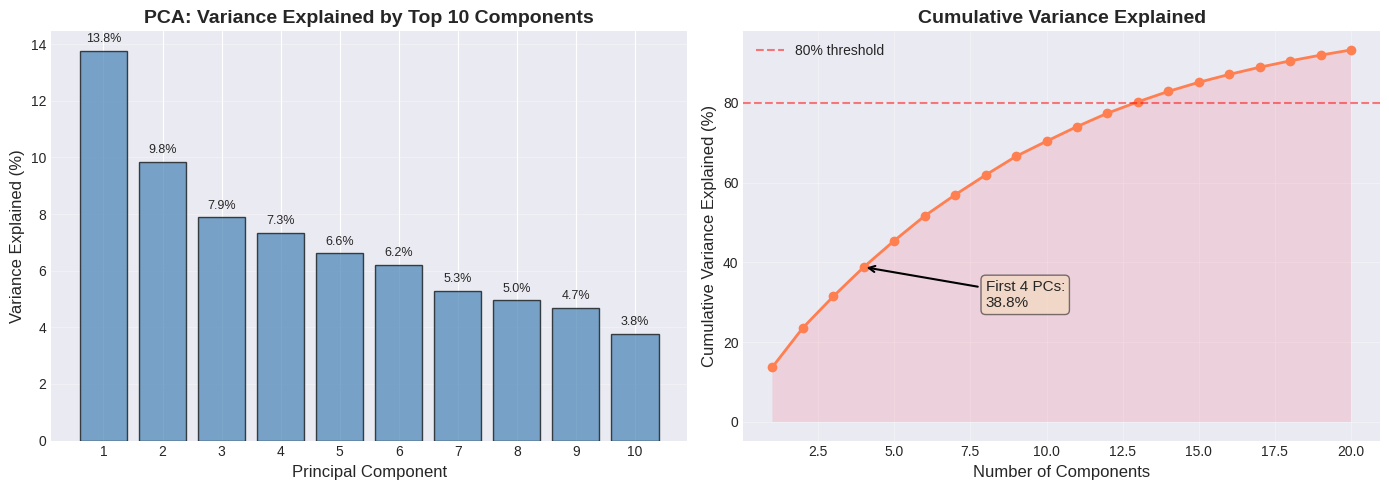

✅ Saved: fig1_pca_variance.png

📊 Figure 2: K-Means Clustering Results...


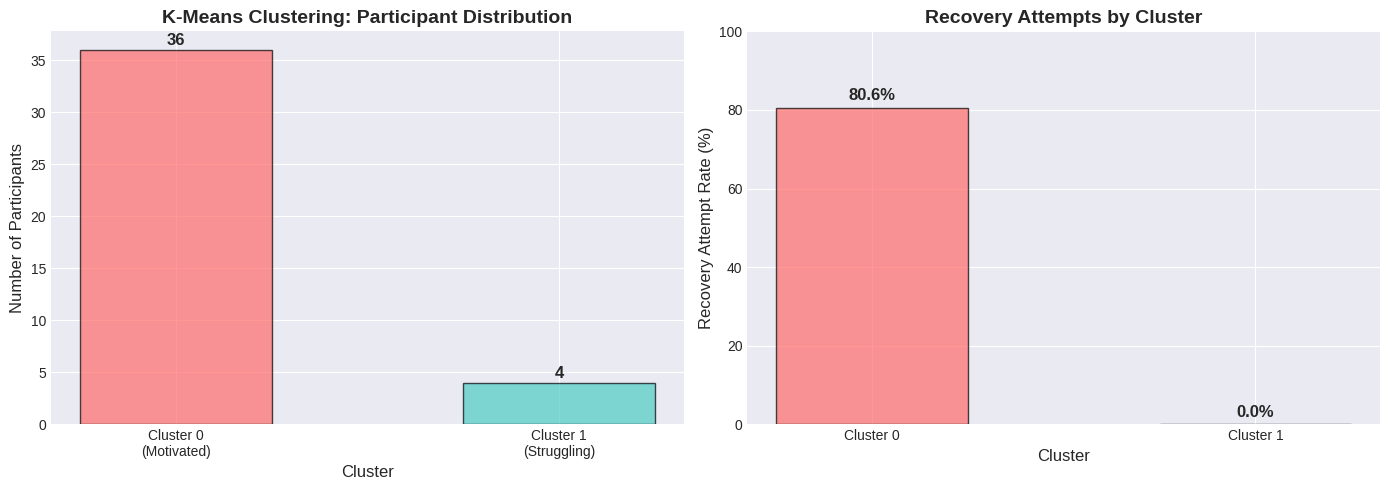

✅ Saved: fig2_clustering.png

📊 Figure 3: Model Performance Comparison...


/tmp/ipykernel_1779/3693664279.py:132: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/3693664279.py:132: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/3693664279.py:132: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/3693664279.py:133: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('fig3_model_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_1779/3693664279.py:133: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('fig3_model_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_1779/3693664279.py:133: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig('fig3_model_comparison.png', dpi=300, b

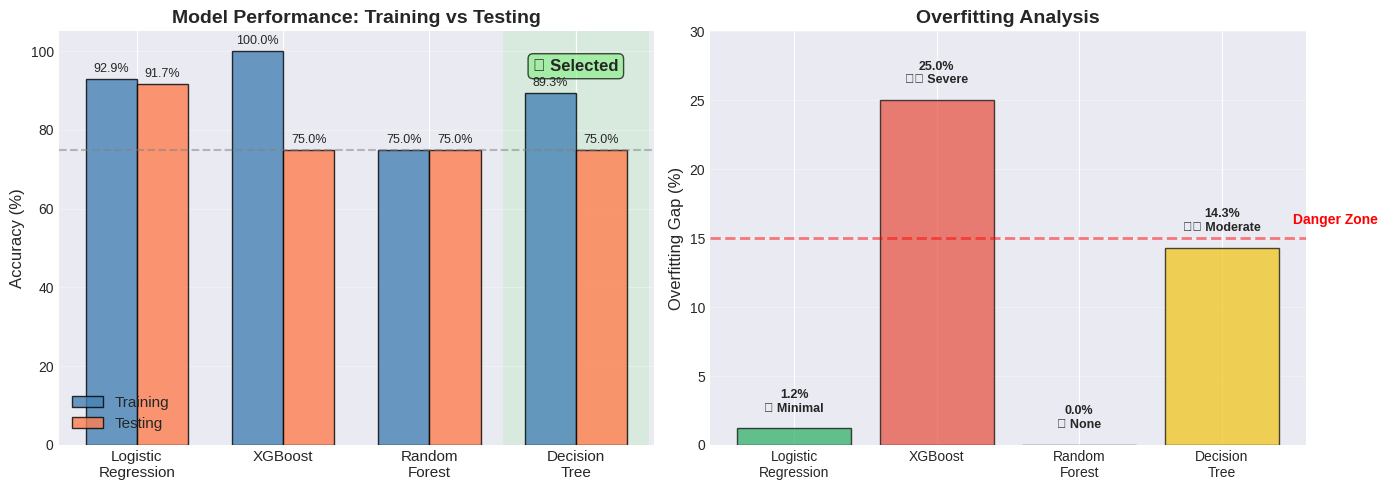

✅ Saved: fig3_model_comparison.png

📊 Figure 4: Feature Importance (Q4 - Recovery Attempts)...


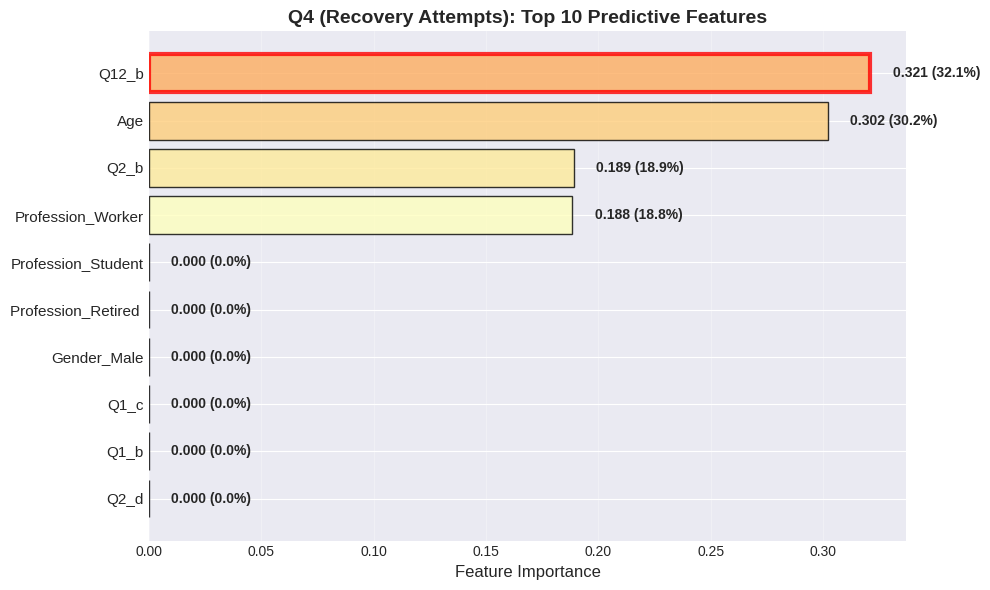

✅ Saved: fig4_features_q4.png

📊 Figure 5: Feature Importance (Q6 - Recovery Success)...


/tmp/ipykernel_1779/3693664279.py:193: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/3693664279.py:194: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.savefig('fig5_features_q6.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


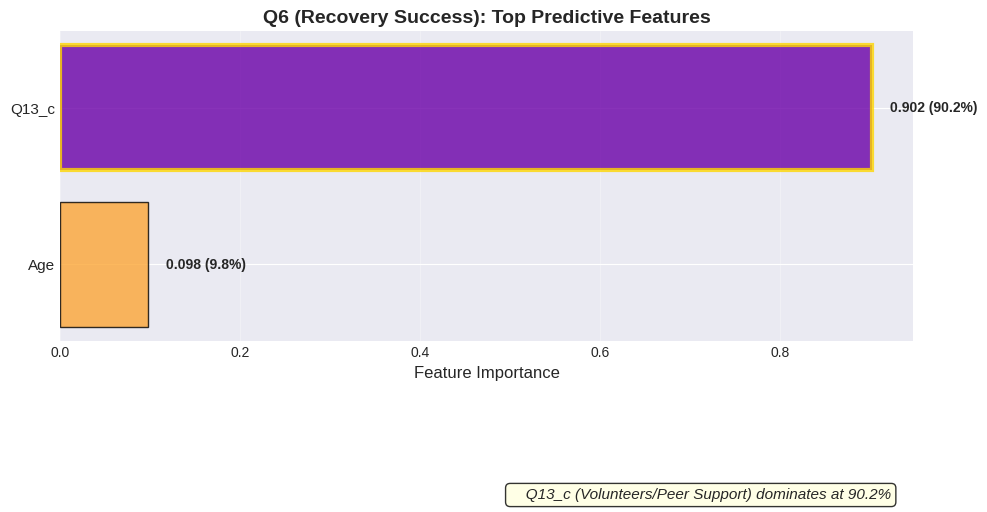

✅ Saved: fig5_features_q6.png

📊 Figure 6: Confusion Matrices Comparison...


/tmp/ipykernel_1779/3693664279.py:228: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/3693664279.py:229: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig('fig6_confusion_matrices.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


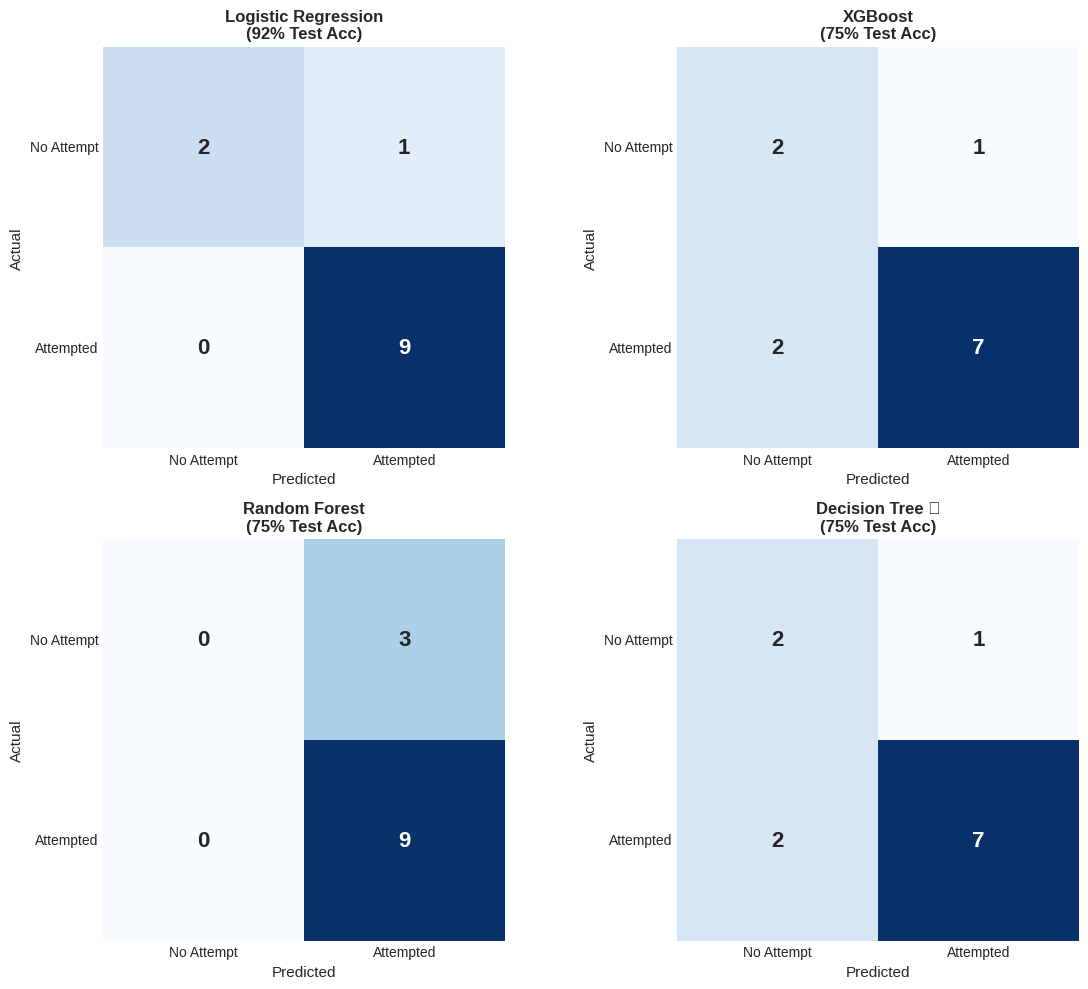

✅ Saved: fig6_confusion_matrices.png

📊 Figure 7: Decision Tree Structure (Q4)...


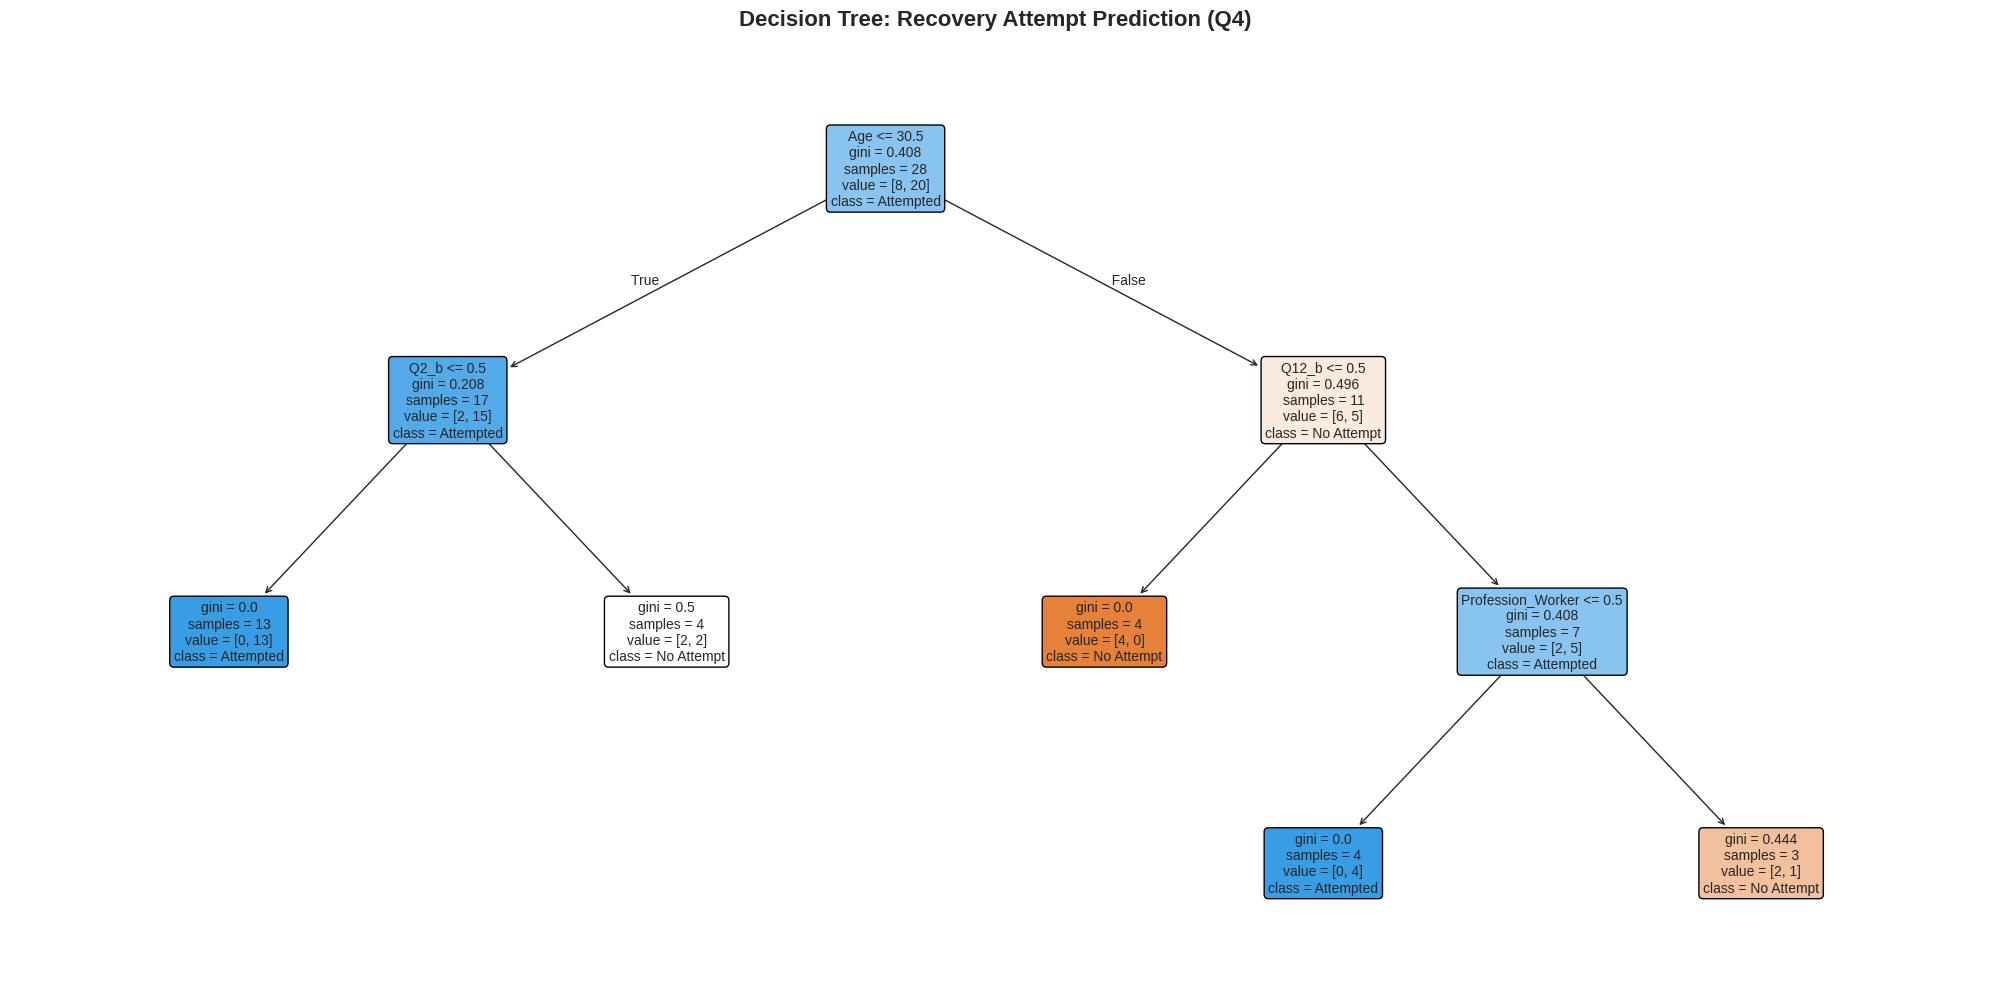

✅ Saved: fig7_decision_tree_q4.png

📊 Figure 8: Q4 vs Q6 Feature Comparison...


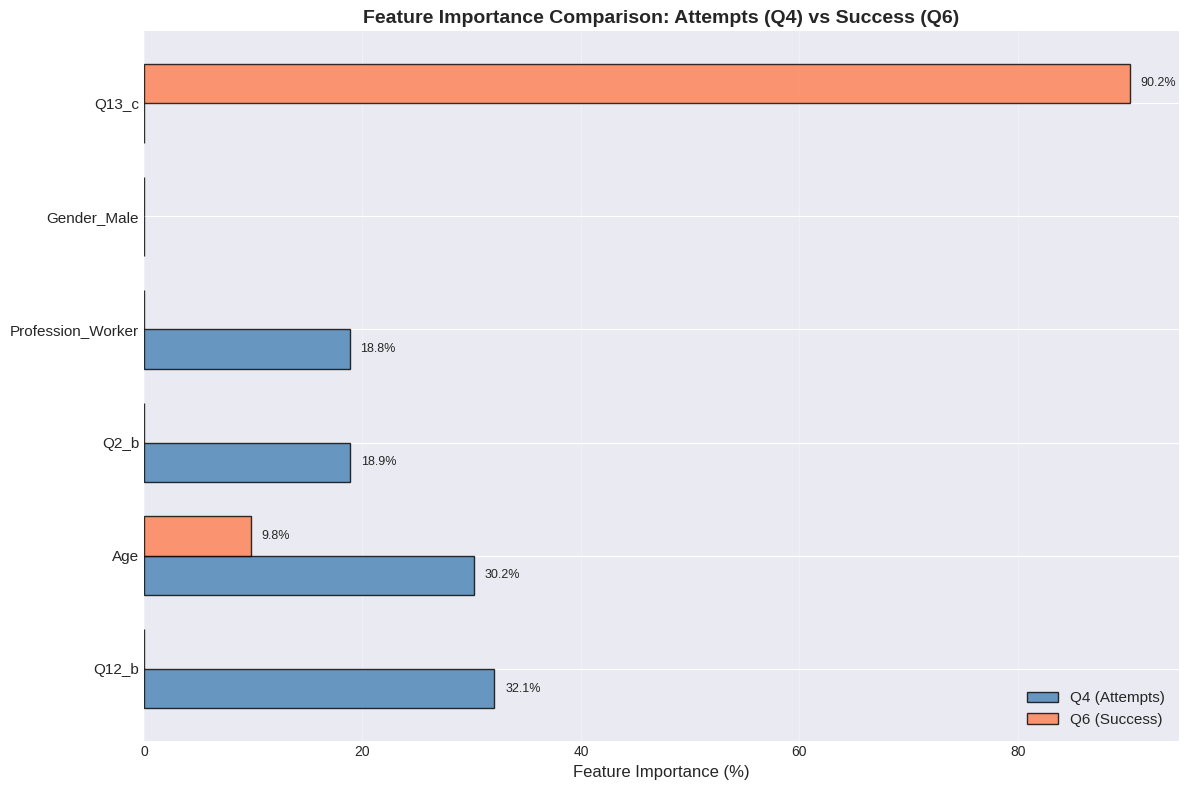

✅ Saved: fig8_q4_vs_q6_comparison.png


In [13]:
# =====================================================
# FIGURES
# =====================================================

print("=" * 70)
print("GENERATING ALL PLOTS FOR PAPER")
print("=" * 70)

# --- Figure 1: PCA Variance ---
print("\n📊 Figure 1: PCA Variance Explained...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

components = range(1, 11)
variance = pca.explained_variance_ratio_[:10] * 100
ax1.bar(components, variance, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained (%)', fontsize=12)
ax1.set_title('PCA: Variance Explained by Top 10 Components',
              fontsize=14, fontweight='bold')
ax1.set_xticks(components)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(variance):
    ax1.text(i + 1, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
ax2.plot(range(1, 21), cumulative[:20], marker='o', linewidth=2,
         markersize=6, color='coral')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax2.fill_between(range(1, 21), cumulative[:20], alpha=0.2)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.annotate(f'First 4 PCs:\n{cumulative[3]:.1f}%',
             xy=(4, cumulative[3]), xytext=(8, cumulative[3] - 10),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig1_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig1_pca_variance.png")

# --- Figure 2: Clustering ---
print("\n📊 Figure 2: K-Means Clustering Results...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_cluster = ['#FF6B6B', '#4ECDC4']

cluster_counts = df["Cluster"].value_counts().sort_index()
ax1.bar(cluster_counts.index, cluster_counts.values,
        color=colors_cluster, alpha=0.7, edgecolor='black', width=0.5)
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Number of Participants', fontsize=12)
ax1.set_title('K-Means Clustering: Participant Distribution',
              fontsize=14, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Cluster 0\n(Motivated)', 'Cluster 1\n(Struggling)'])
for i, v in enumerate(cluster_counts.values):
    ax1.text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')

cluster_attempt = df.groupby("Cluster")["Attempt"].mean() * 100
ax2.bar(cluster_attempt.index, cluster_attempt.values,
        color=colors_cluster, alpha=0.7, edgecolor='black', width=0.5)
ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Recovery Attempt Rate (%)', fontsize=12)
ax2.set_title('Recovery Attempts by Cluster', fontsize=14, fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Cluster 0', 'Cluster 1'])
ax2.set_ylim(0, 100)
for i, v in enumerate(cluster_attempt.values):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_clustering.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig2_clustering.png")

# --- Figure 3: Model Performance ---
print("\n📊 Figure 3: Model Performance Comparison...")

models      = ['Logistic\nRegression', 'XGBoost', 'Random\nForest', 'Decision\nTree']
train_accs  = [92.9, 100.0, 75.0, 89.3]
test_accs   = [91.7,  75.0, 75.0, 75.0]
gaps        = [ 1.2,  25.0,  0.0, 14.3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, train_accs, width, label='Training',
                color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, test_accs,  width, label='Testing',
                color='coral',     alpha=0.8, edgecolor='black')
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Model Performance: Training vs Testing',
              fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.legend(fontsize=11, loc='lower left')
ax1.axhline(y=75, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)
ax1.add_patch(plt.Rectangle((2.5, 0), 1, 105,
              facecolor='lightgreen', alpha=0.2, zorder=0))
ax1.text(3, 95, '✓ Selected', ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

gap_colors = ['#27AE60', '#E74C3C', '#F39C12', '#F1C40F']
bars_gap = ax2.bar(models, gaps, color=gap_colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Overfitting Gap (%)', fontsize=12)
ax2.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax2.axhline(y=15, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.text(3.5, 16, 'Danger Zone', fontsize=10, color='red', fontweight='bold')
ax2.set_ylim(0, 30)
ax2.grid(axis='y', alpha=0.3)
status_labels = ['✓ Minimal', '⚠️ Severe', '✓ None', '⚠️ Moderate']
for bar, gap, label in zip(bars_gap, gaps, status_labels):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{gap:.1f}%\n{label}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig3_model_comparison.png")

# --- Figure 4: Feature Importance Q4 ---
print("\n📊 Figure 4: Feature Importance (Q4 - Recovery Attempts)...")

top_features_q4 = importance_q4.sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
colors_feat = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features_q4)))

bars = ax.barh(range(len(top_features_q4)), top_features_q4.values,
               color=colors_feat, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_features_q4)))
ax.set_yticklabels(top_features_q4.index, fontsize=11)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Q4 (Recovery Attempts): Top 10 Predictive Features',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_features_q4.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f} ({val*100:.1f}%)', va='center',
            fontsize=10, fontweight='bold')
bars[0].set_edgecolor('red')
bars[0].set_linewidth(3)

plt.tight_layout()
plt.savefig('fig4_features_q4.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig4_features_q4.png")

# --- Figure 5: Feature Importance Q6 ---
print("\n📊 Figure 5: Feature Importance (Q6 - Recovery Success)...")

top_features_q6 = importance_q6[importance_q6 > 0].sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
colors_feat_q6 = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_features_q6)))

bars = ax.barh(range(len(top_features_q6)), top_features_q6.values,
               color=colors_feat_q6, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_features_q6)))
ax.set_yticklabels(top_features_q6.index, fontsize=11)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Q6 (Recovery Success): Top Predictive Features',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_features_q6.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f} ({val*100:.1f}%)', va='center',
            fontsize=10, fontweight='bold')
bars[0].set_edgecolor('gold')
bars[0].set_linewidth(3)
ax.text(0.5, len(top_features_q6) + 0.5,
        f'⭐ Q13_c (Volunteers/Peer Support) dominates at '
        f'{top_features_q6.iloc[0]*100:.1f}%',
        fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('fig5_features_q6.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig5_features_q6.png")

# --- Figure 6: Confusion Matrices ---
print("\n📊 Figure 6: Confusion Matrices Comparison...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

cms = [
    confusion_matrix(y_test_c, y_pred_lr),
    confusion_matrix(y_test_c, y_pred_xgb),
    confusion_matrix(y_test_c, y_pred_rf_comp),
    confusion_matrix(y_test_q4, y_pred_q4)
]
titles = [
    'Logistic Regression\n(92% Test Acc)',
    'XGBoost\n(75% Test Acc)',
    'Random Forest\n(75% Test Acc)',
    'Decision Tree ✓\n(75% Test Acc)'
]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                square=True, cbar=False, ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xticklabels(['No Attempt', 'Attempted'])
    ax.set_yticklabels(['No Attempt', 'Attempted'], rotation=0)
axes[3].set_facecolor('#E8F8F5')

plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig6_confusion_matrices.png")

# --- Figure 7: Decision Tree Visualization ---
print("\n📊 Figure 7: Decision Tree Structure (Q4)...")

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_q4,
          feature_names=X_q4.columns,
          class_names=['No Attempt', 'Attempted'],
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Decision Tree: Recovery Attempt Prediction (Q4)',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('fig7_decision_tree_q4.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig7_decision_tree_q4.png")

# --- Figure 8: Q4 vs Q6 Comparison ---
print("\n📊 Figure 8: Q4 vs Q6 Feature Comparison...")

q4_top5 = importance_q4.nlargest(5)
q6_top5 = importance_q6[importance_q6 > 0].nlargest(5)
all_features = list(set(q4_top5.index) | set(q6_top5.index))

comparison_data = pd.DataFrame({
    'Q4_Attempt': [importance_q4.get(f, 0) * 100 for f in all_features],
    'Q6_Success': [importance_q6.get(f, 0) * 100 for f in all_features]
}, index=all_features).sort_values('Q4_Attempt', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(comparison_data))
width = 0.35

bars1 = ax.barh(x - width/2, comparison_data['Q4_Attempt'], width,
                label='Q4 (Attempts)', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.barh(x + width/2, comparison_data['Q6_Success'], width,
                label='Q6 (Success)',  color='coral',     alpha=0.8, edgecolor='black')
ax.set_yticks(x)
ax.set_yticklabels(comparison_data.index, fontsize=11)
ax.set_xlabel('Feature Importance (%)', fontsize=12)
ax.set_title('Feature Importance Comparison: Attempts (Q4) vs Success (Q6)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        width_val = bar.get_width()
        if width_val > 0:
            ax.text(width_val + 1, bar.get_y() + bar.get_height()/2.,
                    f'{width_val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig8_q4_vs_q6_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig8_q4_vs_q6_comparison.png")


📊 Figure 9: Recovery Pipeline Visualization...


/tmp/ipykernel_1779/3636598945.py:80: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1779/3636598945.py:81: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Liberation Sans.
  plt.savefig('fig9_recovery_pipeline.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


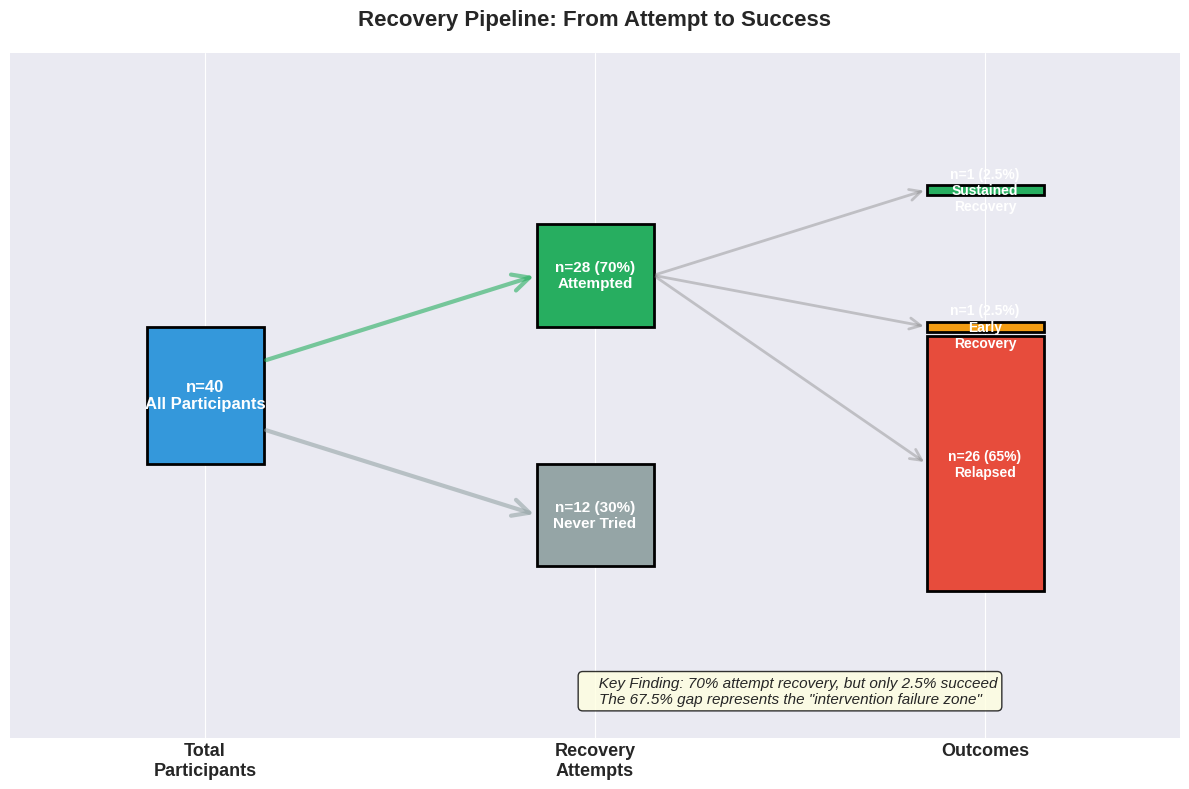

✅ Saved: fig9_recovery_pipeline.png

PLOT GENERATION COMPLETE!

📁 Generated 9 Figures:
  1. fig1_pca_variance.png
  2. fig2_clustering.png
  3. fig3_model_comparison.png
  4. fig4_features_q4.png
  5. fig5_features_q6.png
  6. fig6_confusion_matrices.png
  7. fig7_decision_tree_q4.png
  8. fig8_q4_vs_q6_comparison.png
  9. fig9_recovery_pipeline.png


In [14]:
# =====================================================
# Bonus Figure: Sankey Pipeline!
# =====================================================
print("\n📊 Figure 9: Recovery Pipeline Visualization...")

fig, ax = plt.subplots(figsize=(12, 8))

total       = 40
never_tried = 12
tried       = 28
early_recovery = 1
sustained      = 1
failed         = tried - early_recovery - sustained

box_width = 0.3
colors_pipeline = ['#3498DB', '#27AE60', '#95A5A6', '#E74C3C', '#F39C12']

# Stage 1
ax.add_patch(plt.Rectangle((0 - box_width/2, 0.4), box_width, 0.2,
             facecolor=colors_pipeline[0], edgecolor='black', linewidth=2))
ax.text(0, 0.5, f'n={total}\nAll Participants',
        ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Stage 2
ax.add_patch(plt.Rectangle((1 - box_width/2, 0.6), box_width, 0.15,
             facecolor=colors_pipeline[1], edgecolor='black', linewidth=2))
ax.text(1, 0.675, f'n={tried} (70%)\nAttempted',
        ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax.add_patch(plt.Rectangle((1 - box_width/2, 0.25), box_width, 0.15,
             facecolor=colors_pipeline[2], edgecolor='black', linewidth=2))
ax.text(1, 0.325, f'n={never_tried} (30%)\nNever Tried',
        ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Stage 3
outcomes_y      = [0.8, 0.6, 0.4]
outcomes_n      = [sustained, early_recovery, failed]
outcomes_labels = [
    f'n={sustained} (2.5%)\nSustained\nRecovery',
    f'n={early_recovery} (2.5%)\nEarly\nRecovery',
    f'n={failed} ({failed/total*100:.0f}%)\nRelapsed'
]
outcomes_colors = [colors_pipeline[1], colors_pipeline[4], colors_pipeline[3]]

for y, n, label, color in zip(outcomes_y, outcomes_n, outcomes_labels, outcomes_colors):
    height = n / tried * 0.4
    ax.add_patch(plt.Rectangle((2 - box_width/2, y - height/2), box_width, height,
                 facecolor=color, edgecolor='black', linewidth=2))
    ax.text(2, y, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

# Arrows
ax.add_patch(FancyArrowPatch((0 + box_width/2, 0.55), (1 - box_width/2, 0.675),
             arrowstyle='->', mutation_scale=30, linewidth=3,
             color=colors_pipeline[1], alpha=0.6))
ax.add_patch(FancyArrowPatch((0 + box_width/2, 0.45), (1 - box_width/2, 0.325),
             arrowstyle='->', mutation_scale=30, linewidth=3,
             color=colors_pipeline[2], alpha=0.6))
for y in outcomes_y:
    ax.add_patch(FancyArrowPatch((1 + box_width/2, 0.675), (2 - box_width/2, y),
                 arrowstyle='->', mutation_scale=20, linewidth=2,
                 color='gray', alpha=0.4))

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Total\nParticipants', 'Recovery\nAttempts', 'Outcomes'],
                   fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.set_title('Recovery Pipeline: From Attempt to Success',
             fontsize=16, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.text(1.5, 0.05,
        '💡 Key Finding: 70% attempt recovery, but only 2.5% succeed\n'
        'The 67.5% gap represents the "intervention failure zone"',
        fontsize=11, ha='center', style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('fig9_recovery_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: fig9_recovery_pipeline.png")

# =====================================================
# SUMMARY
# =====================================================

print(f"\n{'='*70}")
print("PLOT GENERATION COMPLETE!")
print("=" * 70)
print("\n📁 Generated 9 Figures:")
for i, name in enumerate([
    "fig1_pca_variance.png",
    "fig2_clustering.png",
    "fig3_model_comparison.png",
    "fig4_features_q4.png",
    "fig5_features_q6.png",
    "fig6_confusion_matrices.png",
    "fig7_decision_tree_q4.png",
    "fig8_q4_vs_q6_comparison.png",
    "fig9_recovery_pipeline.png",
], 1):
    print(f"  {i}. {name}")